# 导入类库和数据

In [1]:
# 导入类库
import numpy as np
from matplotlib import pyplot
from pandas import read_csv
from pandas.plotting import scatter_matrix
from pandas import set_option
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

# 导入数据
filename = 'sonar.all-data.csv'
dataset = read_csv(filename, header = None)

# 优化显示

In [2]:
# 优化
# 1.不显示错误警告
import warnings
warnings.filterwarnings('ignore')

# 2.画图过程中的中文显示
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False     # 修复负号显示问题

# 查看数据

In [3]:
# 数据维度
print(dataset.shape)

# 查看数据类型
set_option('display.max_rows', 500)
print(dataset.dtypes)

# 查看最初的20条记录
set_option('display.width', 100)
print(dataset.head(20))

# 描述性统计信息
set_option('display.precision', 3)
print(dataset.describe())

# 数据的分类分布
print(dataset.groupby(60).size())

(208, 61)
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26    float64
27    float64
28    float64
29    float64
30    float64
31    float64
32    float64
33    float64
34    float64
35    float64
36    float64
37    float64
38    float64
39    float64
40    float64
41    float64
42    float64
43    float64
44    float64
45    float64
46    float64
47    float64
48    float64
49    float64
50    float64
51    float64
52    float64
53    float64
54    float64
55    float64
56    float64
57    float64
58    float64
59    float64
60     object
dtype: object
        0       1       2       3       4       5       6       7       8       9   ...      51  \
0   0.0200  0.0371  0.0

# 可视化查看数据

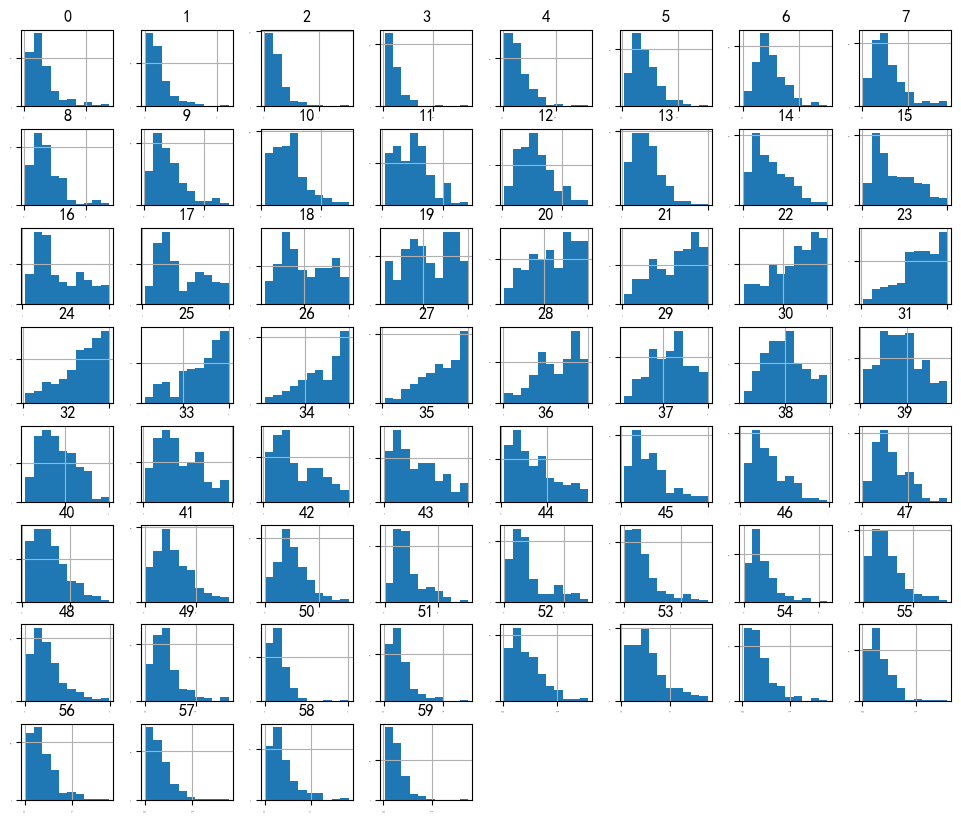

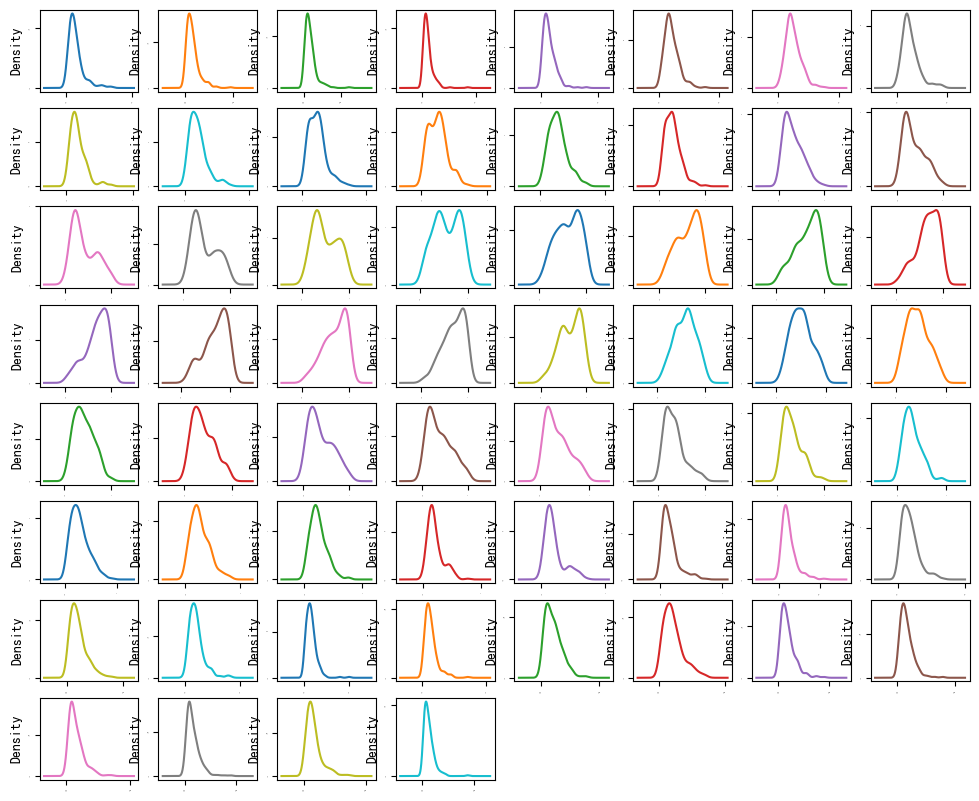

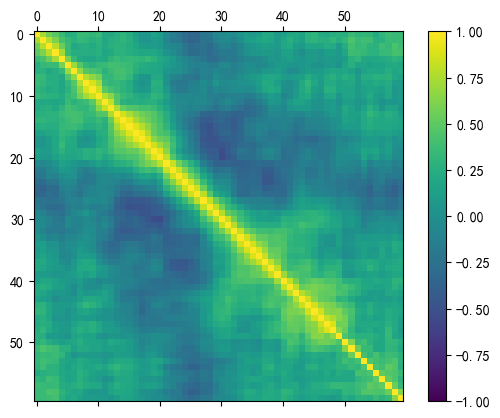

In [4]:
# 直方图
dataset.hist(sharex = False, figsize = (12, 10), sharey = False, xlabelsize = 1, ylabelsize = 1)
pyplot.show()

# 密度图
dataset.plot(kind = 'density', figsize = (12, 10), subplots = True, layout = (8, 8), sharex = False, legend = False, fontsize = 1)
pyplot.show()

numeric_dataset = dataset.iloc[:, :-1] # 最后一列是文本类型，做关系矩阵图会报错
# 关系矩阵图
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(numeric_dataset.corr(), vmin = -1, vmax = 1, interpolation = 'none') # 注意这里修改了dataset为numeric_dataset
fig.colorbar(cax)
pyplot.show()

# 分离数据集
分离X、Y，分类训练集和测试集

In [5]:
# 分离评估数据集
array = dataset.values
X = array[:, 0:60].astype(float)
Y = array[:, 60]
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size = validation_size, random_state = seed)

# 评估算法的基准
num_folds = 10
seed = 7
scoring = 'accuracy'

# 单一算法

LR : 0.777574 (0.088423)
LDA : 0.778676 (0.093570)
KNN : 0.758824 (0.106417)
CART : 0.704779 (0.101687)
NB : 0.682721 (0.136040)
SVM : 0.765074 (0.087519)


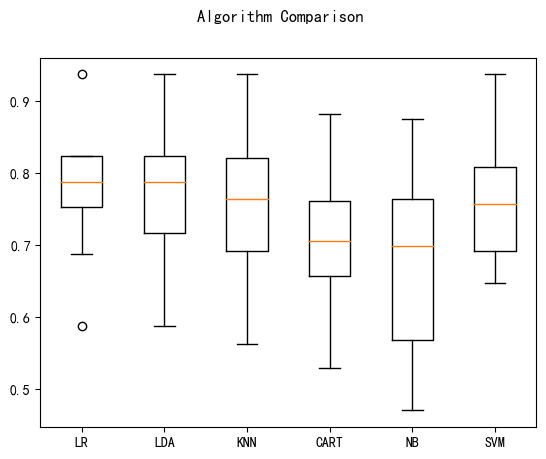

耗时(秒)： 1.4594340324401855


In [6]:
import time
start = time.time()

# 评估算法 - 原始数据，baseline
models = {}
models['LR']   = LogisticRegression()
models['LDA']  = LinearDiscriminantAnalysis()
models['KNN']  = KNeighborsClassifier()
models['CART'] = DecisionTreeClassifier()
models['NB']   = GaussianNB()
models['SVM']  = SVC()
results = []
for key in models:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_results = cross_val_score(models[key], X_train, Y_train, cv = kfold, scoring = scoring)
    results.append(cv_results)
    print('%s : %f (%f)' % (key, cv_results.mean(), cv_results.std()))

# 评估算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(models.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 单一算法：优化
添加数据标准化过程

ScalerLR : 0.754412 (0.067926)
ScalerLDA : 0.778676 (0.093570)
ScalerKNN : 0.808456 (0.107996)
ScalerCART : 0.733456 (0.101477)
ScalerNB : 0.682721 (0.136040)
ScalerSVM : 0.826103 (0.081814)


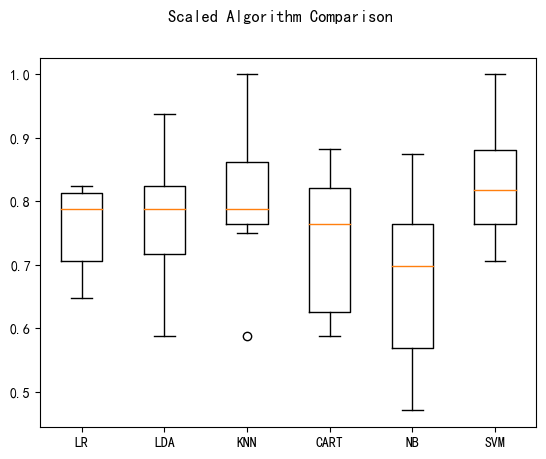

耗时(秒)： 1.1120059490203857


In [7]:
import time
start = time.time()

# 评估算法 - 正态化数据
pipelines = {}
pipelines['ScalerLR']   = Pipeline([('Scaler', StandardScaler()), ('LR', LogisticRegression())])
pipelines['ScalerLDA']  = Pipeline([('Scaler', StandardScaler()), ('LDA', LinearDiscriminantAnalysis())])
pipelines['ScalerKNN']  = Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsClassifier())])
pipelines['ScalerCART'] = Pipeline([('Scaler', StandardScaler()), ('CART', DecisionTreeClassifier())])
pipelines['ScalerNB']   = Pipeline([('Scaler', StandardScaler()), ('NB', GaussianNB())])
pipelines['ScalerSVM']  = Pipeline([('Scaler', StandardScaler()), ('SVM', SVC())])
results = []
for key in pipelines:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_results = cross_val_score(pipelines[key], X_train, Y_train, cv = kfold, scoring = scoring)
    results.append(cv_results)
    print('%s : %f (%f)' % (key, cv_results.mean(), cv_results.std()))

# 评估算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(models.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 单一算法：总结
KNN算法和SVM算法做进一步的参数选择；
KNN算法准确率0.836，耗时0.87秒；
SVM算法准确率0.85，耗时2.94秒；

### 单一算法，KNN

In [8]:
import time
start = time.time()

# 调参改进算法 - KNN
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}
model = KNeighborsClassifier()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)

print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))
cv_results = zip(grid_result.cv_results_['mean_test_score'],
                 grid_result.cv_results_['std_test_score'],
                 grid_result.cv_results_['params'])
for mean, std, param in cv_results:
    print('%f (%f) with %r' % (mean, std, param))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：0.8360294117647058 使用{'n_neighbors': 1}
0.836029 (0.079487) with {'n_neighbors': 1}
0.813603 (0.088021) with {'n_neighbors': 3}
0.814338 (0.096870) with {'n_neighbors': 5}
0.777574 (0.120387) with {'n_neighbors': 7}
0.730147 (0.099376) with {'n_neighbors': 9}
0.741544 (0.073970) with {'n_neighbors': 11}
0.710662 (0.105829) with {'n_neighbors': 13}
0.723162 (0.080983) with {'n_neighbors': 15}
0.698897 (0.072669) with {'n_neighbors': 17}
0.710662 (0.091337) with {'n_neighbors': 19}
0.698897 (0.091195) with {'n_neighbors': 21}
耗时(秒)： 0.8727643489837646


### 单一算法，SVM

In [9]:
import time
start = time.time()

# 调参改进算法 - SVM
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train).astype(float)

param_grid = {}
param_grid['C'] = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
param_grid['kernel'] = ['linear', 'poly', 'rbf', 'sigmoid']

model = SVC()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)

print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))
cv_results = zip(grid_result.cv_results_['mean_test_score'],
                 grid_result.cv_results_['std_test_score'],
                 grid_result.cv_results_['params'])
for mean, std, param in cv_results:
    print('%f (%f) with %r' % (mean, std, param))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：0.85 使用{'C': 1.7, 'kernel': 'rbf'}
0.748529 (0.069953) with {'C': 0.1, 'kernel': 'linear'}
0.582721 (0.127062) with {'C': 0.1, 'kernel': 'poly'}
0.601103 (0.184435) with {'C': 0.1, 'kernel': 'rbf'}
0.712868 (0.116579) with {'C': 0.1, 'kernel': 'sigmoid'}
0.754412 (0.082337) with {'C': 0.3, 'kernel': 'linear'}
0.644118 (0.099873) with {'C': 0.3, 'kernel': 'poly'}
0.742279 (0.081853) with {'C': 0.3, 'kernel': 'rbf'}
0.748529 (0.069953) with {'C': 0.3, 'kernel': 'sigmoid'}
0.765809 (0.070336) with {'C': 0.5, 'kernel': 'linear'}
0.704779 (0.098225) with {'C': 0.5, 'kernel': 'poly'}
0.784559 (0.068922) with {'C': 0.5, 'kernel': 'rbf'}
0.760662 (0.065632) with {'C': 0.5, 'kernel': 'sigmoid'}
0.759926 (0.083206) with {'C': 0.7, 'kernel': 'linear'}
0.759559 (0.093807) with {'C': 0.7, 'kernel': 'poly'}
0.814338 (0.059832) with {'C': 0.7, 'kernel': 'rbf'}
0.761029 (0.079602) with {'C': 0.7, 'kernel': 'sigmoid'}
0.765441 (0.066964) with {'C': 0.9, 'kernel': 'linear'}
0.789706 (0.094189) with {

# 集成算法
2种提升算法，2种装袋算法

ScaledAB: 0.782721 (0.072445)
ScaledGBM: 0.790809 (0.126178)
ScaledRF: 0.826471 (0.114430)
ScaledET: 0.868015 (0.050368)


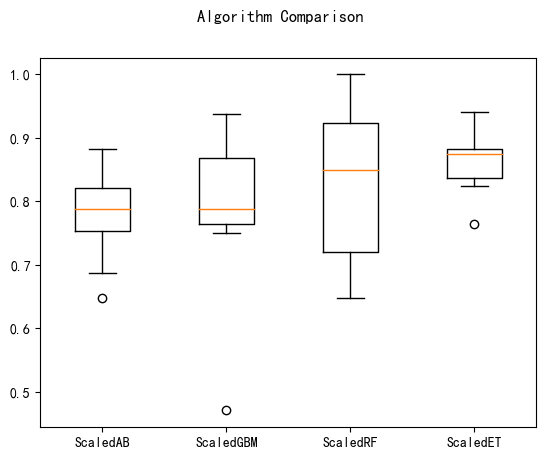

耗时(秒)： 25.720705270767212


In [10]:
import time
start = time.time()

# 集成算法
ensembles = {}
ensembles['ScaledAB']  = Pipeline([('Scaler', StandardScaler()), ('AB', AdaBoostClassifier())])
ensembles['ScaledGBM'] = Pipeline([('Scaler', StandardScaler()), ('GBM', GradientBoostingClassifier())])
ensembles['ScaledRF']  = Pipeline([('Scaler', StandardScaler()), ('RFR', RandomForestClassifier())])
ensembles['ScaledET']  = Pipeline([('Scaler', StandardScaler()), ('ETR', ExtraTreesClassifier())])

results = []
for key in ensembles:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_result = cross_val_score(ensembles[key], X_train, Y_train, cv = kfold, scoring = scoring)
    results.append(cv_result)
    print('%s: %f (%f)' % (key, cv_result.mean(), cv_result.std()))

# 集成算法 - 箱线图
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(ensembles.keys())
pyplot.show()

finish = time.time()
print("耗时(秒)：", finish - start)

### 集成算法调参
随机梯度提升GBM

In [11]:
import time
start = time.time()

# 集成算法GBM - 调参
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_estimators': [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900]}
model = GradientBoostingClassifier()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)
print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：0.8316176470588236 使用{'n_estimators': 200}
耗时(秒)： 441.63810420036316


# 集成算法调参：极端随机树ET
上面的结果看，ET算法准确率0.86，并且标准差也是最小的

In [12]:
import time
start = time.time()

# 集成算法GBM - 调参
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
param_grid = {'n_estimators': [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900]}

model = ExtraTreesClassifier()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = rescaledX, y = Y_train)
print('最优：%s 使用%s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优：0.8801470588235294 使用{'n_estimators': 800}
耗时(秒)： 91.9387035369873


### 最终模型
支持向量机SVC，最优参数C = 1.7, kernel = 'rbf'

In [15]:
# 模型最终化
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = SVC(C = 1.7, kernel = 'rbf')
model.fit(X = rescaledX, y = Y_train)
# 评估模型
rescaled_validationX = scaler.transform(X_validation)
predictions = model.predict(rescaled_validationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.9285714285714286
[[25  2]
 [ 1 14]]
              precision    recall  f1-score   support

           M       0.96      0.93      0.94        27
           R       0.88      0.93      0.90        15

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.92        42
weighted avg       0.93      0.93      0.93        42



# 最终模型：ET

In [16]:
# 模型最终化
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

model = ExtraTreesClassifier(n_estimators = 800)
model.fit(X = rescaledX, y = Y_train)
# 评估模型
rescaled_validationX = scaler.transform(X_validation)
predictions = model.predict(rescaled_validationX)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8809523809523809
[[23  4]
 [ 1 14]]
              precision    recall  f1-score   support

           M       0.96      0.85      0.90        27
           R       0.78      0.93      0.85        15

    accuracy                           0.88        42
   macro avg       0.87      0.89      0.88        42
weighted avg       0.89      0.88      0.88        42

